In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# -----------------------------
# 1. Load the data
# -----------------------------
data = pd.read_csv('../Data/OldSensorNodeData.csv', parse_dates=['Timestamp'])

In [19]:
data.head()

,Timestamp,AQI,Temp,Hum,Pres
0,2025-12-07 23:51:11,65.32,21.4,73,0
1,2025-12-07 23:51:16,60.56,21.4,71,0
2,2025-12-07 23:51:21,57.26,21.4,71,0
3,2025-12-07 23:51:26,52.87,21.4,70,0
4,2025-12-07 23:51:31,50.79,21.4,69,0


In [20]:
# -----------------------------
# 2. Extract timestamp features
# -----------------------------
data['hour'] = data['Timestamp'].dt.hour
data['minute'] = data['Timestamp'].dt.minute
data['second'] = data['Timestamp'].dt.second
data['day_of_week'] = data['Timestamp'].dt.dayofweek

In [21]:
data.head()

,Timestamp,AQI,Temp,Hum,Pres,hour,minute,second,day_of_week
0,2025-12-07 23:51:11,65.32,21.4,73,0,23,51,11,6
1,2025-12-07 23:51:16,60.56,21.4,71,0,23,51,16,6
2,2025-12-07 23:51:21,57.26,21.4,71,0,23,51,21,6
3,2025-12-07 23:51:26,52.87,21.4,70,0,23,51,26,6
4,2025-12-07 23:51:31,50.79,21.4,69,0,23,51,31,6


<Axes: ylabel='Temp'>

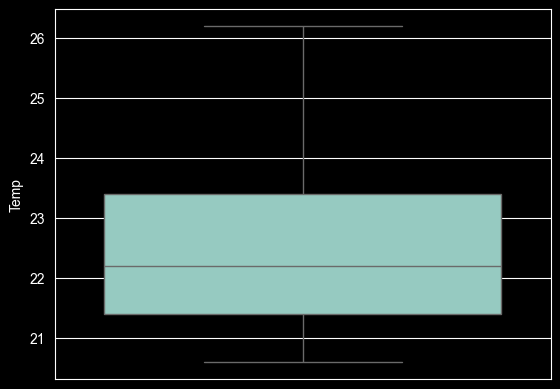

In [22]:
sns.boxplot(data[data['Temp']> 10]['Temp'])

In [23]:
# -----------------------------
# 3. Prepare features and targets
# -----------------------------
# Features: current sensor readings + timestamp features
feature_cols = ['AQI', 'Temp', 'Hum', 'Pres', 'hour', 'minute', 'second']
X = data[feature_cols].copy()

# Targets: AQI, Temp, Hum for 1, 5, 15 min ahead
# Assuming 5-second intervals:
def shift_target(df, col, steps):
    return df[col].shift(-steps)

X['AQI_1min'] = shift_target(data, 'AQI', 12)     # 1 min ahead
X['AQI_5min'] = shift_target(data, 'AQI', 60)     # 5 min ahead
X['AQI_15min'] = shift_target(data, 'AQI', 180)   # 15 min ahead

X['Temp_1min'] = shift_target(data, 'Temp', 12)
X['Temp_5min'] = shift_target(data, 'Temp', 60)
X['Temp_15min'] = shift_target(data, 'Temp', 180)

X['Hum_1min'] = shift_target(data, 'Hum', 12)
X['Hum_5min'] = shift_target(data, 'Hum', 60)
X['Hum_15min'] = shift_target(data, 'Hum', 180)

# Drop rows with NaN targets (end of dataset)
X.dropna(inplace=True)

# Separate features and targets
feature_cols_final = ['AQI', 'Temp', 'Hum', 'Pres', 'hour', 'minute', 'second']
target_cols = ['AQI_1min','AQI_5min','AQI_15min',
               'Temp_1min','Temp_5min','Temp_15min',
               'Hum_1min','Hum_5min','Hum_15min']

X_final = X[feature_cols_final]
y_final = X[target_cols]
X

,AQI,Temp,Hum,Pres,hour,minute,second,AQI_1min,AQI_5min,AQI_15min,Temp_1min,Temp_5min,Temp_15min,Hum_1min,Hum_5min,Hum_15min
0,65.32,21.4,73,0,23,51,11,41.03,37.85,38.46,21.4,21.0,21.0,68.0,70.0,71.0
1,60.56,21.4,71,0,23,51,16,41.03,37.73,38.22,21.4,21.0,21.0,68.0,70.0,71.0
2,57.26,21.4,71,0,23,51,21,41.03,39.44,37.97,21.4,21.0,21.0,68.0,70.0,71.0
3,52.87,21.4,70,0,23,51,26,39.19,37.73,38.46,21.4,21.0,21.0,68.0,70.0,71.0
4,50.79,21.4,69,0,23,51,31,38.46,37.73,38.46,21.4,21.0,21.0,68.0,70.0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45543,72.89,21.0,52,0,15,31,3,73.50,74.24,82.17,21.0,21.0,22.2,53.0,53.0,54.0
45544,72.28,21.0,52,0,15,31,8,73.02,74.60,81.93,21.0,21.0,22.2,53.0,53.0,54.0
45545,72.89,21.0,52,1,15,31,13,73.02,74.36,82.66,21.0,21.0,22.2,53.0,53.0,54.0
45546,72.89,21.0,52,1,15,31,19,73.38,74.48,83.27,21.0,21.0,22.2,53.0,53.0,54.0


In [24]:
# -----------------------------
# 4. Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)


In [25]:
# -----------------------------
# 5. Chronological Train/Test Split
# -----------------------------
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_final[:split_idx], y_final[split_idx:]
print('Preprocessing done. Ready for Linear Regression!')

Preprocessing done. Ready for Linear Regression!


In [26]:
# -----------------------------
# 1. Initialize and train model
# -----------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# -----------------------------
# 2. Make predictions
# -----------------------------

y_pred = lr_model.predict(X_test)

In [28]:
# -----------------------------
# 3. Evaluate performance
# -----------------------------

# Prepare DataFrame to hold metrics
metrics = pd.DataFrame(columns=['Target', 'MAE', 'RMSE', 'R2'])

# List of targets
targets = y_test.columns

# Compute metrics per target
for i, target in enumerate(targets):
    y_true = y_test[target].values
    y_hat = y_pred[:, i]

    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    r2 = r2_score(y_true, y_hat)

    metrics.loc[i] = [target, mae, rmse, r2]

# Compute combined metrics (average)
combined_mae = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')
combined_rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='uniform_average'))
combined_r2 = r2_score(y_test, y_pred, multioutput='uniform_average')

metrics.loc[len(targets)] = ['Combined', combined_mae, combined_rmse, combined_r2]

# Display metrics
print(metrics)


       Target       MAE      RMSE        R2
0    AQI_1min  0.257064  0.670053  0.980175
1    AQI_5min  0.511589  1.804826  0.856820
2   AQI_15min  1.157469  3.154847  0.564720
3   Temp_1min  0.939851  1.246692 -1.035650
4   Temp_5min  0.951748  1.255394 -1.076137
5  Temp_15min  1.001577  1.314123 -1.150265
6    Hum_1min  2.576195  3.245200 -2.109221
7    Hum_5min  2.592123  3.261150 -2.148803
8   Hum_15min  2.762323  3.435491 -2.213762
9    Combined  1.416660  2.391783 -0.814680


In [29]:
# -----------------------------
# 4. Optional: show first few predictions vs actuals
# -----------------------------

# Prepare DataFrame of predictions
comparison = pd.DataFrame(y_pred, columns=y_test.columns)

# Add corresponding timestamps
comparison['Timestamp'] = data['Timestamp'].iloc[split_idx:split_idx+len(y_pred)].values

# Reorder columns: Timestamp first
comparison = comparison[['Timestamp'] + list(y_test.columns)]

# Prepare actual values (first 5 rows)
comparison_actual = y_test.reset_index(drop=True).head(5)

# Side-by-side view: first 5 rows
side_by_side = pd.concat([comparison.head(5), comparison_actual], axis=1)

print("First 5 Predictions vs Actuals:")
side_by_side

First 5 Predictions vs Actuals:


,Timestamp,AQI_1min,AQI_5min,AQI_15min,Temp_1min,Temp_5min,Temp_15min,Hum_1min,Hum_5min,Hum_15min,AQI_1min,AQI_5min,AQI_15min,Temp_1min,Temp_5min,Temp_15min,Hum_1min,Hum_5min,Hum_15min
0,2025-12-10 02:48:18,79.414924,79.261579,78.947864,23.151923,23.131109,23.137131,55.519833,55.451790,55.398733,79.49,79.37,79.73,22.6,22.6,22.6,55.0,54.0,55.0
1,2025-12-10 02:48:23,79.653984,79.497809,79.181391,23.155480,23.134796,23.139827,55.528992,55.460406,55.404311,79.85,79.49,79.98,22.6,22.6,22.6,55.0,54.0,55.0
2,2025-12-10 02:48:28,79.691599,79.555143,79.591396,23.103786,23.066368,23.020715,55.411941,55.365815,55.511765,79.98,79.49,79.00,22.6,22.6,22.6,55.0,54.0,55.0
3,2025-12-10 02:48:33,79.773333,79.614389,79.299076,23.157166,23.136788,23.139821,55.532766,55.464081,55.403923,79.98,79.73,79.73,22.6,22.6,22.6,55.0,54.0,55.0
4,2025-12-10 02:48:38,79.653624,79.494738,79.183236,23.155295,23.135093,23.137120,55.527382,55.459142,55.397958,73.14,79.00,79.73,22.6,22.6,22.6,55.0,55.0,55.0


In [30]:
# Take first N rows for plotting (optional, full test set may be too long)
N = len(y_test)  # or N = 200 for shorter plot
timestamps = data['Timestamp'].iloc[split_idx:split_idx+N]

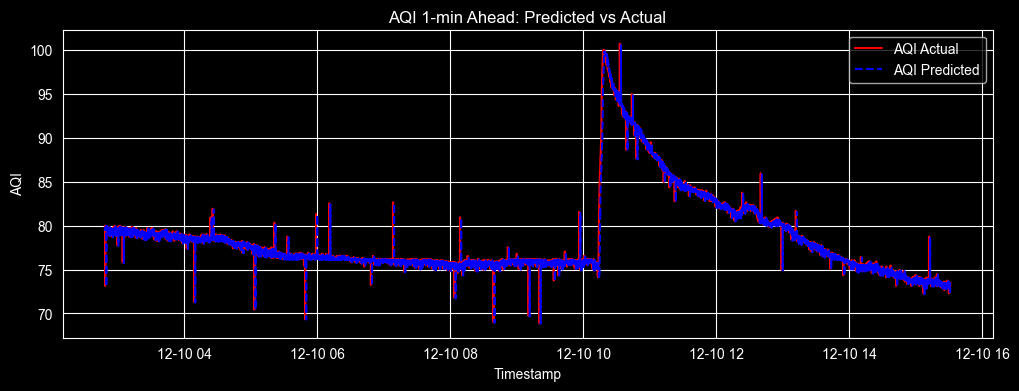

In [31]:
# Plot AQI
plt.figure(figsize=(12, 4))
plt.plot(timestamps, y_test['AQI_1min'][:N], label='AQI Actual', color='red')
plt.plot(timestamps, y_pred[:N, 0], label='AQI Predicted', color='blue', linestyle='--')
plt.title('AQI 1-min Ahead: Predicted vs Actual')
plt.xlabel('Timestamp')
plt.ylabel('AQI')
plt.legend()
plt.show()

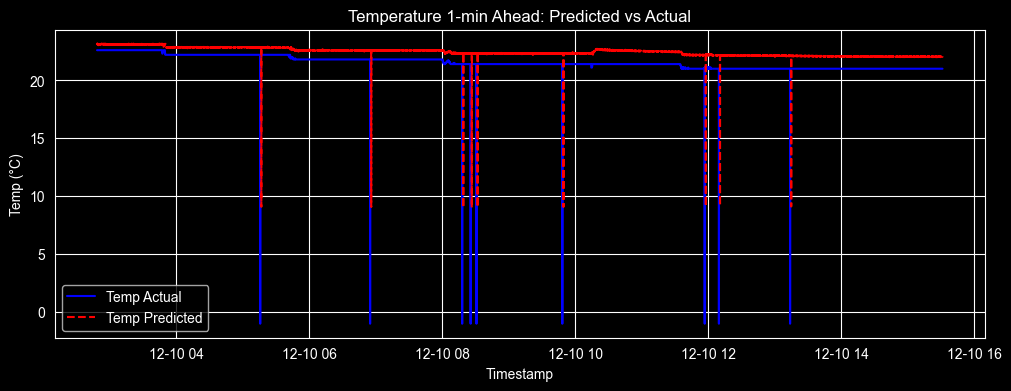

In [32]:
# Plot Temp
plt.figure(figsize=(12, 4))
plt.plot(timestamps, y_test['Temp_1min'][:N], label='Temp Actual', color='blue')
plt.plot(timestamps, y_pred[:N, 3], label='Temp Predicted', color='red', linestyle='--')
plt.title('Temperature 1-min Ahead: Predicted vs Actual')
plt.xlabel('Timestamp')
plt.ylabel('Temp (°C)')
plt.legend()
plt.show()

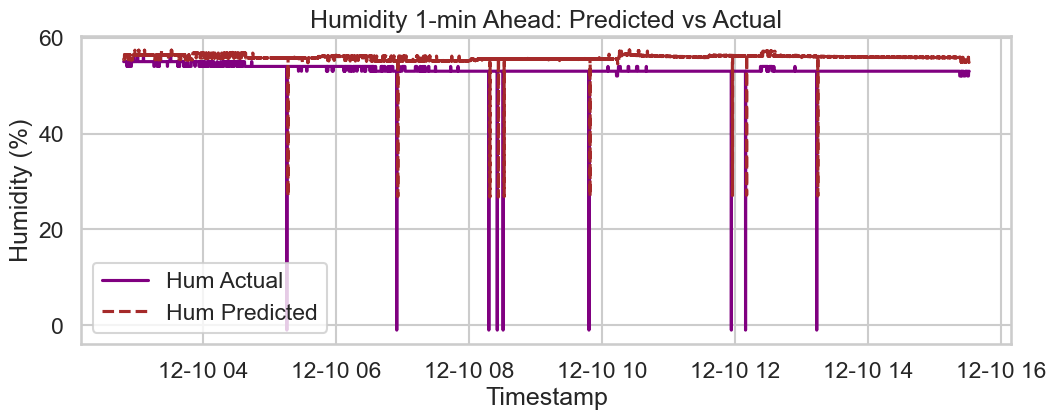

In [42]:
# Plot Humidity
plt.figure(figsize=(12, 4))
plt.plot(timestamps, y_test['Hum_1min'][:N], label='Hum Actual', color='purple')
plt.plot(timestamps, y_pred[:N, 6], label='Hum Predicted', color='brown', linestyle='--')
plt.title('Humidity 1-min Ahead: Predicted vs Actual')
plt.xlabel('Timestamp')
plt.ylabel('Humidity (%)')
plt.legend()
plt.show()

In [44]:
# Combine predictions and actuals into a single DataFrame for plotting
plot_df = pd.DataFrame({
    'Timestamp': data['Timestamp'].iloc[split_idx:split_idx+len(y_pred)],
    'AQI_Actual': y_test['AQI_1min'].values,
    'AQI_Predicted': y_pred[:, 0],
    'Temp_Actual': y_test['Temp_1min'].values,
    'Temp_Predicted': y_pred[:, 3],
    'Hum_Actual': y_test['Hum_1min'].values,
    'Hum_Predicted': y_pred[:, 6]
})

In [45]:
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_context("talk")  # bigger labels for presentation

# Plot function
def plot_var(actual_col, pred_col, ylabel, title):
    plt.figure(figsize=(14, 5))
    sns.lineplot(x='Timestamp', y=actual_col, data=plot_df, label='Actual', color='blue')
    sns.lineplot(x='Timestamp', y=pred_col, data=plot_df, label='Predicted', color='orange', linestyle='--')
    plt.title(title)
    plt.xlabel('Timestamp')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

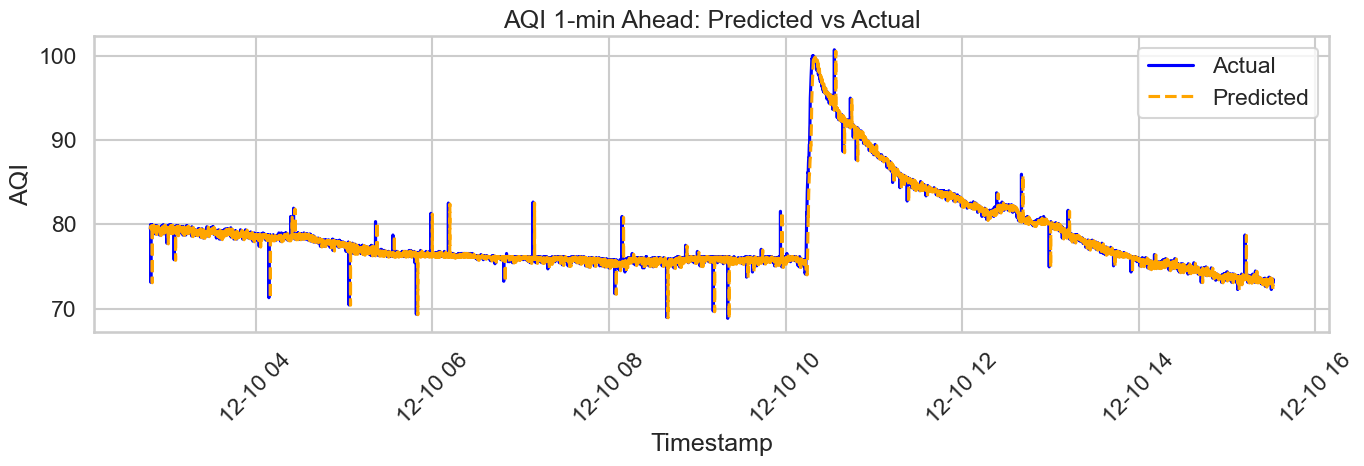

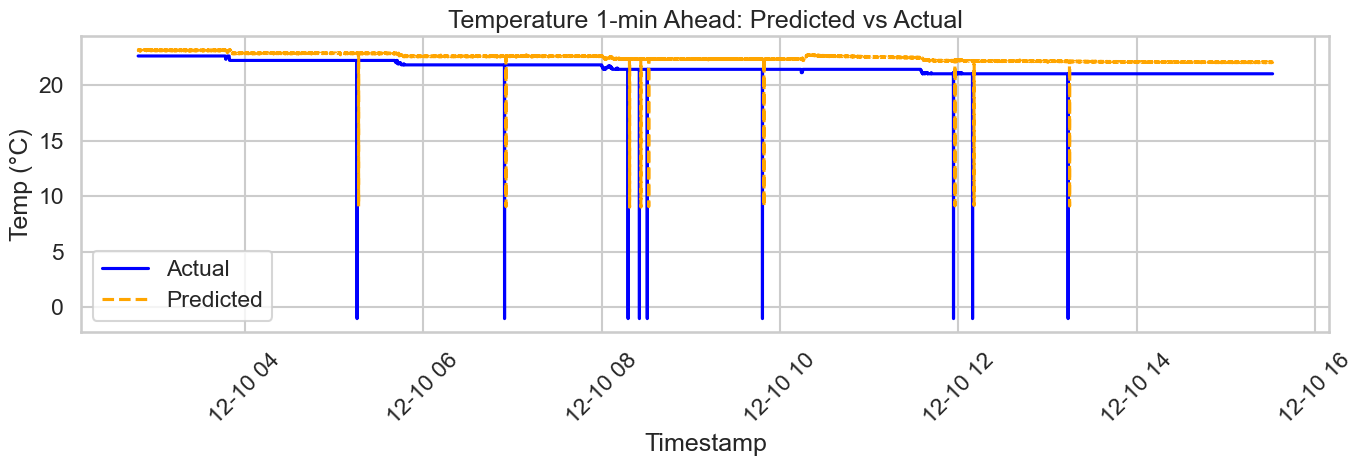

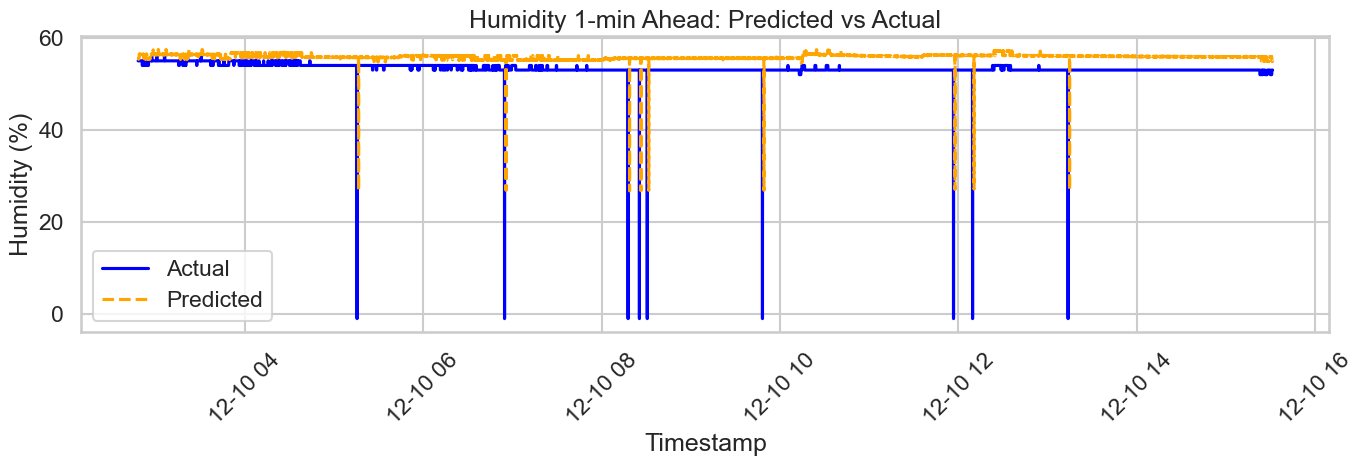

In [46]:
# AQI
plot_var('AQI_Actual', 'AQI_Predicted', 'AQI', 'AQI 1-min Ahead: Predicted vs Actual')

# Temperature
plot_var('Temp_Actual', 'Temp_Predicted', 'Temp (°C)', 'Temperature 1-min Ahead: Predicted vs Actual')

# Humidity
plot_var('Hum_Actual', 'Hum_Predicted', 'Humidity (%)', 'Humidity 1-min Ahead: Predicted vs Actual')


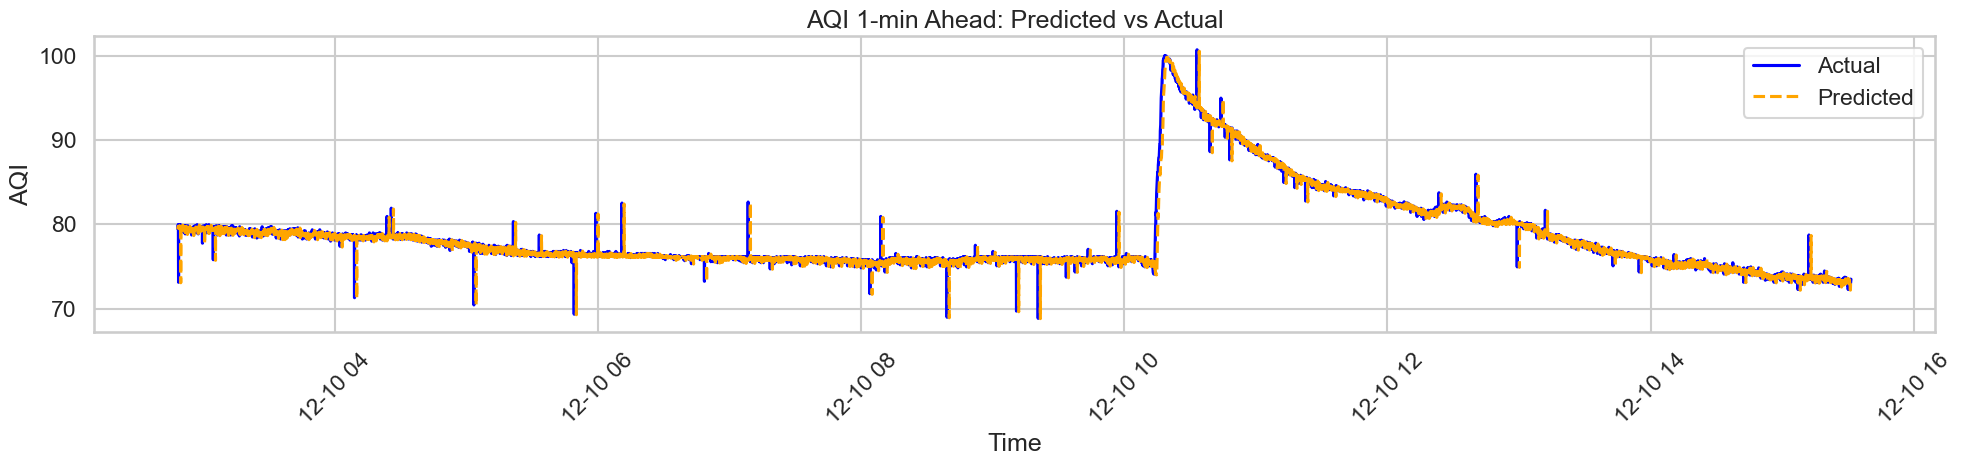

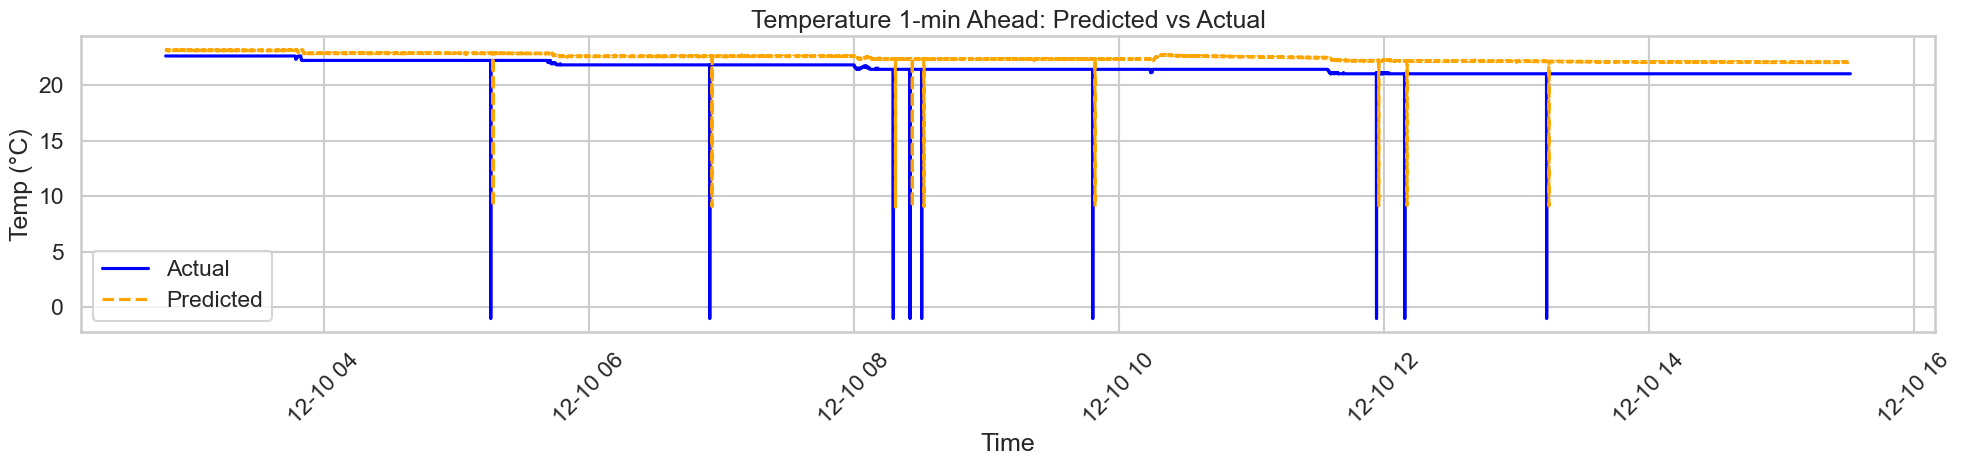

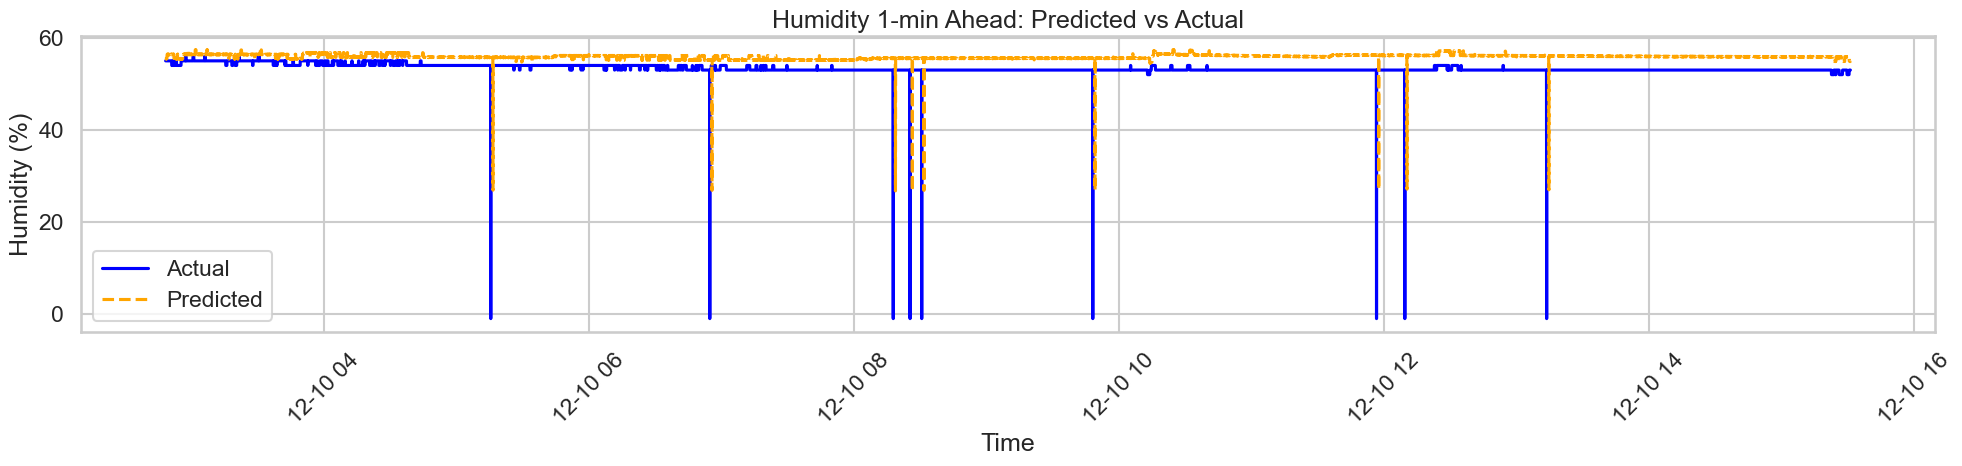

In [16]:
# Use timestamps for x-axis
timestamps = data['Timestamp'].iloc[split_idx:split_idx+len(y_pred)]

# Combine predictions and actuals into DataFrame
plot_df = pd.DataFrame({
    'Timestamp': timestamps,
    'AQI_Actual': y_test['AQI_1min'].values,
    'AQI_Predicted': y_pred[:, 0],
    'Temp_Actual': y_test['Temp_1min'].values,
    'Temp_Predicted': y_pred[:, 3],
    'Hum_Actual': y_test['Hum_1min'].values,
    'Hum_Predicted': y_pred[:, 6]
})

sns.set_style("whitegrid")
sns.set_context("talk")  # bigger fonts

def plot_var_time(actual_col, pred_col, ylabel, title):
    plt.figure(figsize=(20, 5))  # wide figure
    sns.lineplot(x='Timestamp', y=actual_col, data=plot_df, label='Actual', color='blue')
    sns.lineplot(x='Timestamp', y=pred_col, data=plot_df, label='Predicted', color='orange', linestyle='--')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

# AQI
plot_var_time('AQI_Actual', 'AQI_Predicted', 'AQI', 'AQI 1-min Ahead: Predicted vs Actual')

# Temp
plot_var_time('Temp_Actual', 'Temp_Predicted', 'Temp (°C)', 'Temperature 1-min Ahead: Predicted vs Actual')

# Humidity
plot_var_time('Hum_Actual', 'Hum_Predicted', 'Humidity (%)', 'Humidity 1-min Ahead: Predicted vs Actual')
